# ETF 组合分析与评估工具

本工具基于 **AkShare** 自动爬取 ETF 历史行情，计算绩效指标，并自动生成
**单只 ETF 的定位与修改建议** 以及 **投资组合的综合评估报告**。

## 数据源（二选一，改 `DATA_SOURCE` 一个字即可切换）
- `'eastmoney'`：AkShare → 东方财富（`fund_etf_hist_em`，前复权 qfq，更严谨）
- `'sina'`：AkShare → 新浪财经（`fund_etf_hist_sina`，不复权，连接更稳定）

## 计算指标
区间收益率 · 年化波动率 · 最大回撤 · 夏普比率 · ETF 间相关性矩阵 ·
流动性（规模 / 日均成交额 / 折溢价率，可自动获取或手动输入）

## 评估方法论（源自《操作策略》：建候选池 → 过四道关 → 核心/卫星分类）
1. **关卡1 流动性**：规模≥10亿、日均成交额≥2000万、|折溢价|≤1%；QDII/跨境品种折溢价分三档——**≤5% 很棒、5%~8% 略有风险（仍放行）、>8% 风险大才淘汰**。其余不达标直接 **淘汰**。
2. **关卡2 波动与回撤**：年化波动率 < 20% 且 最大回撤 > -10% → 可作 **核心（求稳，约70-80%仓位）**。
3. **关卡3 趋势与动量**：均线多头排列（MA5>MA10>MA20）且区间收益为正 → 可作 **卫星（求收益，约20-30%仓位）**；否则 **观察**。
4. **关卡4 相关性**：核心与卫星、卫星之间尽量低相关，以压低组合回撤、抬高组合夏普。

> ⚠️ 所有指标都是「向后看」的历史表现，不能预测未来；它帮你客观横向排序、搭稳健结构，最终仍需结合趋势、事件风险等定性判断。

---
**使用方法**：只需修改下面【参数配置区】这一个单元格，然后菜单 `Kernel → Restart & Run All` 即可。

In [1]:
# ============================================================
# 【参数配置区】——你只需要改这一个单元格
# ============================================================

# 数据源切换：'eastmoney'(东方财富, 前复权)  或  'sina'(新浪, 连接更稳)
DATA_SOURCE = 'sina'

# 待分析的 ETF：{名称: 6位代码}（代码不用加 sh/sz 前缀，程序会按数据源自动处理）
ETF_LIST = {
    '沪深300ETF华泰柏瑞': '510300',   # 核心候选 · 宽基
    '红利低波ETF南方':   '515450',   # 核心候选 · 红利低波
    '10年国债ETF国泰':   '511260',   # 核心候选 · 利率债
    '黄金ETF华安':       '518880',   # 商品 · 近期偏高波动
    '纳指ETF嘉实':       '159501',   # 跨境
    '通信ETF国泰':       '515880',   # 卫星 · 行业
    '证券ETF国泰':       '512880',   # 卫星 · 行业
    '科创芯片ETF嘉实':   '588200',   # 卫星 · 高波动高弹性
}

# 组合权重（名称需与 ETF_LIST 一致；程序会自动归一化）
PORTFOLIO = {
    '沪深300ETF华泰柏瑞': 0.25,
    '红利低波ETF南方':   0.20,
    '10年国债ETF国泰':   0.25,
    '黄金ETF华安':       0.05,
    '纳指ETF嘉实':       0.05,
    '通信ETF国泰':       0.05,
    '证券ETF国泰':       0.05,
    '科创芯片ETF嘉实':   0.10,
}

# 时间范围（含起止），格式 YYYYMMDD
START = '20260101'
END   = '20260606'

# 想要重点出「定位与修改建议」的单只 ETF（设为 None 则对全部逐只输出）
FOCUS_ETF = '科创芯片ETF嘉实'

# ---- 年化与无风险利率 ----
TRADING_DAYS = 252       # 年化用交易日数
RF_ANNUAL    = 0.018     # 无风险年化收益（如不考虑设 0.0）

# ---- 分类门槛（源自评分表「参数设置」，可自行调整）----
SCALE_MIN_YI      = 10      # 规模门槛（亿元），低于则淘汰
TURNOVER_MIN_WAN  = 2000    # 日均成交额门槛（万元），低于则淘汰
PREMIUM_CAP_PCT      = 1.0     # 普通ETF折溢价率上限（绝对值, %），超过则淘汰
# QDII/跨境ETF折溢价三档（绝对值,%）：≤GOOD很棒 / GOOD~WARN略有风险 / >WARN风险大(淘汰)
QDII_PREMIUM_GOOD    = 5.0     # ≤5% 很棒（放行；海外休市致IOPV滞后，折溢价天然偏大）
QDII_PREMIUM_WARN    = 8.0     # 5%~8% 略有风险（仍放行但提示）；>8% 风险大（淘汰）
QDII_ETF = set()               # 手动指定哪些算QDII/跨境（按名称），与下面关键字识别合并，例: {'某ETF'}
QDII_KEYWORDS = ['纳指','纳斯达克','标普','道琼斯','美国','恒生','港股','日经','日本','德国','法国',
                 '欧洲','越南','印度','亚太','海外','全球','中概','QDII','原油','石油']  # 名称含关键字自动按QDII阈值
CORE_VOL_CAP      = 0.20    # 核心：年化波动率上限
CORE_MDD_CAP      = -0.10   # 核心：最大回撤上限（负数，越接近0越好）
CORR_HIGH         = 0.80    # 相关性「过高/重叠」阈值

# ---- 流动性数据 ----
AUTO_LIQUIDITY = True       # True=尝试用 akshare 实时获取规模/折溢价；失败则用下面手填
# 手动流动性（自动获取失败或想覆盖时用）：{名称: {'规模亿':.., '日均成交额万':.., '折溢价':..}}
MANUAL_LIQUIDITY = {
    # '某ETF': {'规模亿': 50, '日均成交额万': 8000, '折溢价': 0.1},
}

OUTPUT_XLSX = 'ETF分析结果.xlsx'   # 结果导出文件名
OUTPUT_HTML = 'ETF分析报告.html'   # 可视化 HTML 报告文件名

In [2]:
import time, socket
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
socket.setdefaulttimeout(15)
import warnings; warnings.filterwarnings('ignore')

try:
    import akshare as ak
except ImportError:
    ak = None
    print('未安装 akshare，请先在终端执行： pip install akshare')

# 中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline
print('数据源 =', DATA_SOURCE, '| akshare', getattr(ak, '__version__', '未安装'))

# —— 图表转 base64，供 HTML 报告内嵌 ——
import io, base64
CHARTS = {}
def _b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=130, bbox_inches='tight')
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('ascii')


数据源 = sina | akshare 1.18.64


## 1. 自动爬取历史行情

In [3]:
def to_sina_symbol(code):
    # 6位代码转新浪带前缀：5/6开头 -> sh，1/0/3开头 -> sz
    c = str(code).strip()
    return ('sh' + c) if c[0] in '56' else ('sz' + c)

def fetch_history(code, source=DATA_SOURCE, start=START, end=END, retries=3):
    # 返回标准化 DataFrame: 列 = [date, close, amount(成交额,元)]
    if ak is None:
        raise RuntimeError('未安装 akshare')
    last_err = None
    for i in range(retries):
        try:
            if source == 'eastmoney':
                df = ak.fund_etf_hist_em(symbol=str(code), period='daily',
                                         start_date=start, end_date=end, adjust='qfq')
                df = df.rename(columns={'日期': 'date', '收盘': 'close', '成交额': 'amount'})
            else:
                df = ak.fund_etf_hist_sina(symbol=to_sina_symbol(code))
            df['date'] = pd.to_datetime(df['date'])
            df = df[(df['date'] >= pd.to_datetime(start)) & (df['date'] <= pd.to_datetime(end))]
            out = pd.DataFrame({
                'date': df['date'].values,
                'close': pd.to_numeric(df['close']).values,
                'amount': pd.to_numeric(df['amount']).values,
            })
            return out.sort_values('date').reset_index(drop=True)
        except Exception as e:
            last_err = e
            print(f'  {code} 第{i+1}次取数失败：{e}')
            time.sleep(2)
    raise RuntimeError(f'取数失败（{code}）：{last_err}')

# 逐只抓取，拼成「收盘价表」与「成交额表」
close_dict, amount_dict = {}, {}
for name, code in ETF_LIST.items():
    print(f'抓取 {name} ({code}) …')
    df = fetch_history(code)
    if df.empty:
        print(f'  ⚠ {name} 在该窗口内无数据，已跳过')
        continue
    close_dict[name] = pd.Series(df['close'].values, index=df['date'].values)
    amount_dict[name] = pd.Series(df['amount'].values, index=df['date'].values)

if not close_dict:
    raise RuntimeError('没有取到任何数据，请检查代码/日期/网络')

# 按共同交易日对齐
price_df = pd.DataFrame(close_dict).sort_index().dropna()
amount_df = pd.DataFrame(amount_dict).sort_index().reindex(price_df.index)
ret_df = price_df.pct_change().dropna()

print(f'\n数据区间：{str(price_df.index.min())[:10]} ~ {str(price_df.index.max())[:10]}，'
      f'对齐后共 {len(price_df)} 个交易日，{price_df.shape[1]} 只 ETF')
price_df.tail()

抓取 沪深300ETF华泰柏瑞 (510300) …


抓取 红利低波ETF南方 (515450) …


抓取 10年国债ETF国泰 (511260) …


抓取 黄金ETF华安 (518880) …


抓取 纳指ETF嘉实 (159501) …


抓取 通信ETF国泰 (515880) …


抓取 证券ETF国泰 (512880) …


抓取 科创芯片ETF嘉实 (588200) …



数据区间：2026-01-05 ~ 2026-06-05，对齐后共 100 个交易日，8 只 ETF


,沪深300ETF华泰柏瑞,红利低波ETF南方,10年国债ETF国泰,黄金ETF华安,纳指ETF嘉实,通信ETF国泰,证券ETF国泰,科创芯片ETF嘉实
2026-06-01,4.868,1.446,136.091,9.344,2.200,1.532,1.035,3.370
2026-06-02,4.936,1.443,136.140,9.410,2.185,1.635,1.037,3.445
2026-06-03,4.965,1.432,136.078,9.281,2.153,1.716,1.035,3.571
2026-06-04,4.926,1.417,136.133,9.290,2.107,1.708,1.022,3.622
2026-06-05,4.843,1.416,136.071,9.252,2.087,1.663,1.016,3.456


## 2. 绩效指标：区间收益率 / 年化波动率 / 最大回撤 / 夏普比率 / 动量

In [4]:
def max_drawdown(price_series):
    p = price_series.dropna()
    return (p / p.cummax() - 1).min()

def ma_bull(price_series):
    # 均线多头排列：MA5 > MA10 > MA20（数据不足则 NaN）
    p = price_series.dropna()
    if len(p) < 20:
        return np.nan
    ma5, ma10, ma20 = p.rolling(5).mean().iloc[-1], p.rolling(10).mean().iloc[-1], p.rolling(20).mean().iloc[-1]
    return bool(ma5 > ma10 > ma20)

def metrics(price_series):
    p = price_series.dropna()
    r = p.pct_change().dropna()
    ann_vol = r.std(ddof=1) * np.sqrt(TRADING_DAYS)
    ann_ret = r.mean() * TRADING_DAYS
    ret20 = p.iloc[-1] / p.iloc[-min(len(p), 21)] - 1   # 近20交易日动量
    return {
        '区间收益率': p.iloc[-1] / p.iloc[0] - 1,
        '年化波动率': ann_vol,
        '最大回撤':   max_drawdown(p),
        '夏普比率':   (ann_ret - RF_ANNUAL) / ann_vol if ann_vol > 0 else np.nan,
        '近20日动量': ret20,
        '多头排列':   ma_bull(p),
        '样本天数':   len(p),
    }

metric_rows = {name: metrics(price_df[name]) for name in price_df.columns}
metric_df = pd.DataFrame(metric_rows).T

def pct(x):
    return f'{x*100:6.2f}%' if pd.notna(x) else '   n/a'

show = metric_df.copy()
for c in ['区间收益率', '年化波动率', '最大回撤', '近20日动量']:
    show[c] = show[c].map(pct)
show['夏普比率'] = show['夏普比率'].map(lambda x: f'{x:5.2f}' if pd.notna(x) else 'n/a')
show[['区间收益率', '年化波动率', '最大回撤', '夏普比率', '近20日动量', '多头排列', '样本天数']]

,区间收益率,年化波动率,最大回撤,夏普比率,近20日动量,多头排列,样本天数
沪深300ETF华泰柏瑞,-0.02%,16.27%,-9.94%,-0.03,-0.88%,False,100
红利低波ETF南方,1.29%,11.53%,-4.43%,0.18,-0.91%,False,100
10年国债ETF国泰,1.74%,1.48%,-0.73%,1.76,0.66%,True,100
黄金ETF华安,-2.56%,38.56%,-24.89%,-0.02,-6.36%,False,100
纳指ETF嘉实,16.14%,22.85%,-13.02%,1.70,9.50%,True,100
通信ETF国泰,-47.09%,113.94%,-68.91%,-0.43,16.29%,True,100
证券ETF国泰,-17.73%,20.81%,-21.07%,-2.37,-5.93%,False,100
科创芯片ETF嘉实,40.89%,44.94%,-19.30%,2.13,6.63%,False,100


## 3. 流动性数据（自动获取规模/折溢价，日均成交额由窗口内成交额计算；可手动覆盖）

In [5]:
# 日均成交额（万元）= 窗口内每日成交额均值 / 1e4
avg_turnover_wan = (amount_df.mean() / 1e4).round(1)

# 实时规模(亿)与折溢价(%)：东方财富 fund_etf_spot_em
scale_yi = pd.Series(index=price_df.columns, dtype=float)
premium_pct = pd.Series(index=price_df.columns, dtype=float)

if AUTO_LIQUIDITY and ak is not None:
    try:
        print('获取实时流动性快照（fund_etf_spot_em）…')
        spot = ak.fund_etf_spot_em()
        spot['代码'] = spot['代码'].astype(str).str.zfill(6)
        spot = spot.set_index('代码')
        for name, code in ETF_LIST.items():
            if name not in price_df.columns:
                continue
            c = str(code).zfill(6)
            if c in spot.index:
                row = spot.loc[c]
                scale_yi[name] = float(row['总市值']) / 1e8 if pd.notna(row['总市值']) else np.nan
                premium_pct[name] = float(row['基金折价率']) if pd.notna(row['基金折价率']) else np.nan
    except Exception as e:
        print('  实时流动性获取失败，改用手填/留空：', e)

# 手动覆盖
for name, d in MANUAL_LIQUIDITY.items():
    if name in price_df.columns:
        if '规模亿' in d:      scale_yi[name] = d['规模亿']
        if '日均成交额万' in d: avg_turnover_wan[name] = d['日均成交额万']
        if '折溢价' in d:      premium_pct[name] = d['折溢价']

liquidity_df = pd.DataFrame({
    '规模(亿)': scale_yi.round(1),
    '日均成交额(万)': avg_turnover_wan,
    '折溢价率(%)': premium_pct.round(3),
})
liquidity_df

获取实时流动性快照（fund_etf_spot_em）…


  0%|          | 0/14 [00:00<?, ?it/s]

,规模(亿),日均成交额(万),折溢价率(%)
沪深300ETF华泰柏瑞,1339.7,642384.8,-0.06
红利低波ETF南方,182.1,17467.8,-0.01
10年国债ETF国泰,NaN,441784.4,NaN
黄金ETF华安,983.0,692978.4,-0.09
纳指ETF嘉实,127.2,13785.1,-9.45
通信ETF国泰,377.9,211299.0,0.04
证券ETF国泰,537.0,207846.2,0.02
科创芯片ETF嘉实,424.2,369354.0,0.20


## 4. 四道关分类：核心 / 卫星 / 观察 / 淘汰

In [6]:
# QDII/跨境ETF识别：海外休市时IOPV滞后，折溢价天然偏大，单独用更宽容的阈值
def is_qdii(name):
    return (name in QDII_ETF) or any(k in str(name) for k in QDII_KEYWORDS)

def premium_grade(name, premium):
    # 返回 (评级, 是否淘汰, 淘汰原因)；QDII 用三档，普通ETF 用 1% 硬门槛
    if pd.isna(premium):
        return '未知', False, ''
    a = abs(premium)
    if is_qdii(name):
        if a <= QDII_PREMIUM_GOOD:
            return '很棒', False, ''
        if a <= QDII_PREMIUM_WARN:
            return '略有风险', False, ''
        return '风险大', True, f'折溢价{premium:.2f}%超{QDII_PREMIUM_WARN}%(风险大)'
    if a <= PREMIUM_CAP_PCT:
        return '正常', False, ''
    return '风险大', True, f'折溢价{premium:.2f}%超{PREMIUM_CAP_PCT}%'

# 流动性「硬门槛」：仅当数据存在且突破阈值时才算不达标（缺失不直接淘汰，标为待补充）
def liquidity_reasons(name, scale, turnover, premium):
    rs = []
    if pd.notna(scale) and scale < SCALE_MIN_YI:
        rs.append(f'规模{scale:.1f}亿<{SCALE_MIN_YI}亿')
    if pd.notna(turnover) and turnover < TURNOVER_MIN_WAN:
        rs.append(f'日均成交{turnover:.0f}万<{TURNOVER_MIN_WAN}万')
    _, elim, why = premium_grade(name, premium)
    if elim:
        rs.append(why)
    return rs

def missing_liquidity(scale, turnover, premium):
    miss = []
    if pd.isna(scale):    miss.append('规模')
    if pd.isna(turnover): miss.append('日均成交额')
    if pd.isna(premium):  miss.append('折溢价')
    return miss

def classify(name):
    m = metric_df.loc[name]
    scale = liquidity_df.loc[name, '规模(亿)']
    turn  = liquidity_df.loc[name, '日均成交额(万)']
    prem  = liquidity_df.loc[name, '折溢价率(%)']
    reasons = liquidity_reasons(name, scale, turn, prem)
    if reasons:
        return '淘汰', '；'.join(reasons)
    miss = missing_liquidity(scale, turn, prem)
    tail = f'（流动性待补充：{"、".join(miss)}）' if miss else ''
    if premium_grade(name, prem)[0] == '略有风险':
        tail += f'（QDII折溢价{prem:.2f}%，略有风险）'
    if m['年化波动率'] < CORE_VOL_CAP and m['最大回撤'] > CORE_MDD_CAP:
        return '核心', '低波动+浅回撤，适合打底求稳' + tail
    bull = (m['多头排列'] == True)
    mom_pos = pd.notna(m['近20日动量']) and m['近20日动量'] > 0
    if m['区间收益率'] > 0 and (bull or mom_pos):
        return '卫星', '有正动量/多头排列，可做进攻' + tail
    return '观察', '动量不足或处于回调，暂观望' + tail

cls_rows = []
for name in price_df.columns:
    role, note = classify(name)
    m = metric_df.loc[name]
    cls_rows.append({
        'ETF名称': name,
        '区间收益率': m['区间收益率'], '年化波动率': m['年化波动率'],
        '最大回撤': m['最大回撤'], '夏普比率': m['夏普比率'],
        '规模(亿)': liquidity_df.loc[name, '规模(亿)'],
        '日均成交额(万)': liquidity_df.loc[name, '日均成交额(万)'],
        '折溢价率(%)': liquidity_df.loc[name, '折溢价率(%)'],
        '折溢价评级': premium_grade(name, liquidity_df.loc[name, '折溢价率(%)'])[0],
        '多头排列': m['多头排列'], '建议分类': role, '判定说明': note,
    })
score_df = pd.DataFrame(cls_rows).set_index('ETF名称')

show2 = score_df.copy()
for c in ['区间收益率', '年化波动率', '最大回撤']:
    show2[c] = show2[c].map(pct)
show2['夏普比率'] = show2['夏普比率'].map(lambda x: f'{x:5.2f}' if pd.notna(x) else 'n/a')
print('分类统计：', dict(score_df['建议分类'].value_counts()))
show2[['区间收益率','年化波动率','最大回撤','夏普比率','规模(亿)','日均成交额(万)','折溢价率(%)','折溢价评级','建议分类','判定说明']]

分类统计： {'核心': np.int64(3), '观察': np.int64(3), '淘汰': np.int64(1), '卫星': np.int64(1)}


,区间收益率,年化波动率,最大回撤,夏普比率,规模(亿),日均成交额(万),折溢价率(%),折溢价评级,建议分类,判定说明
ETF名称,,,,,,,,,,
沪深300ETF华泰柏瑞,-0.02%,16.27%,-9.94%,-0.03,1339.7,642384.8,-0.06,正常,核心,低波动+浅回撤，适合打底求稳
红利低波ETF南方,1.29%,11.53%,-4.43%,0.18,182.1,17467.8,-0.01,正常,核心,低波动+浅回撤，适合打底求稳
10年国债ETF国泰,1.74%,1.48%,-0.73%,1.76,NaN,441784.4,NaN,未知,核心,低波动+浅回撤，适合打底求稳（流动性待补充：规模、折溢价）
黄金ETF华安,-2.56%,38.56%,-24.89%,-0.02,983.0,692978.4,-0.09,正常,观察,动量不足或处于回调，暂观望
纳指ETF嘉实,16.14%,22.85%,-13.02%,1.70,127.2,13785.1,-9.45,风险大,淘汰,折溢价-9.45%超8.0%(风险大)
通信ETF国泰,-47.09%,113.94%,-68.91%,-0.43,377.9,211299.0,0.04,正常,观察,动量不足或处于回调，暂观望
证券ETF国泰,-17.73%,20.81%,-21.07%,-2.37,537.0,207846.2,0.02,正常,观察,动量不足或处于回调，暂观望
科创芯片ETF嘉实,40.89%,44.94%,-19.30%,2.13,424.2,369354.0,0.20,正常,卫星,有正动量/多头排列，可做进攻


## 5. 相关性矩阵（近窗口日收益；越接近1越同涨同跌，选低相关的搭配）

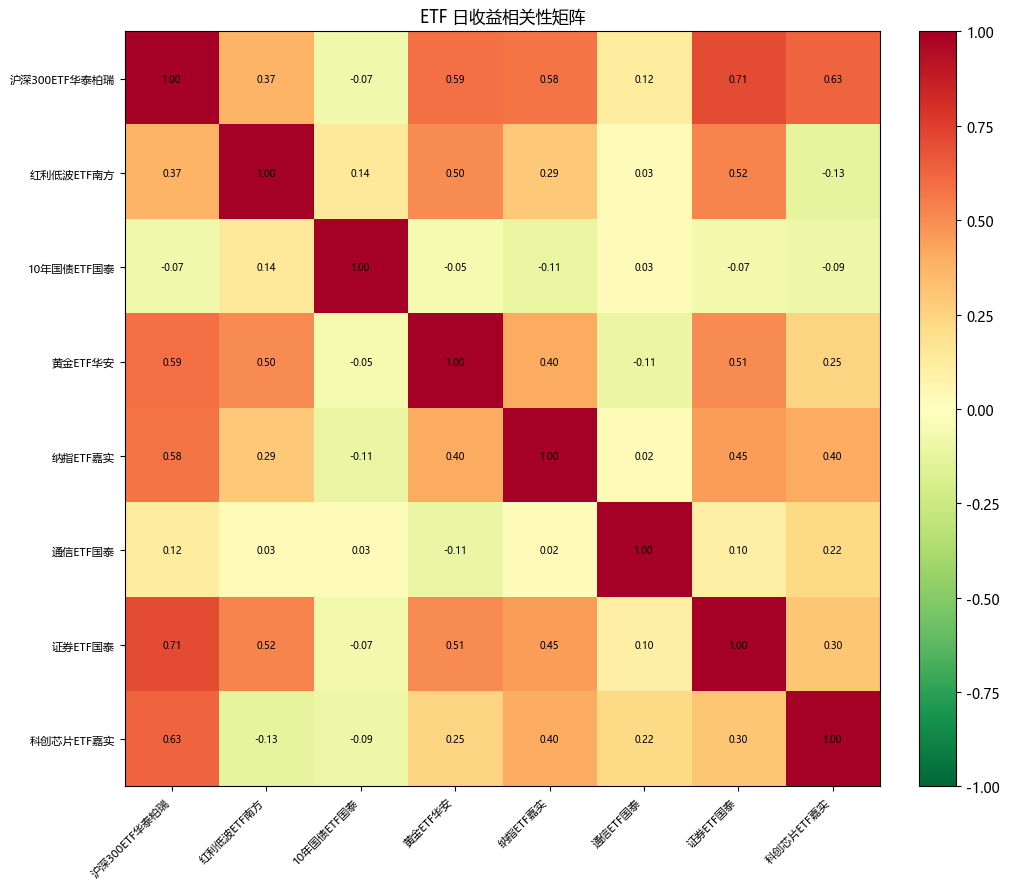

,沪深300ETF华泰柏瑞,红利低波ETF南方,10年国债ETF国泰,黄金ETF华安,纳指ETF嘉实,通信ETF国泰,证券ETF国泰,科创芯片ETF嘉实
沪深300ETF华泰柏瑞,1.00,0.37,-0.07,0.59,0.58,0.12,0.71,0.63
红利低波ETF南方,0.37,1.00,0.14,0.50,0.29,0.03,0.52,-0.13
10年国债ETF国泰,-0.07,0.14,1.00,-0.05,-0.11,0.03,-0.07,-0.09
黄金ETF华安,0.59,0.50,-0.05,1.00,0.40,-0.11,0.51,0.25
纳指ETF嘉实,0.58,0.29,-0.11,0.40,1.00,0.02,0.45,0.40
通信ETF国泰,0.12,0.03,0.03,-0.11,0.02,1.00,0.10,0.22
证券ETF国泰,0.71,0.52,-0.07,0.51,0.45,0.10,1.00,0.30
科创芯片ETF嘉实,0.63,-0.13,-0.09,0.25,0.40,0.22,0.30,1.00


In [7]:
corr = ret_df.corr()

fig, ax = plt.subplots(figsize=(1.1*len(corr)+2, 1.0*len(corr)+1))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdYlGn_r')
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr.index, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=7)
ax.set_title('ETF 日收益相关性矩阵')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
CHARTS['corr'] = _b64(fig)
plt.show()
corr.round(2)

## 6. 净值走势与组合模拟

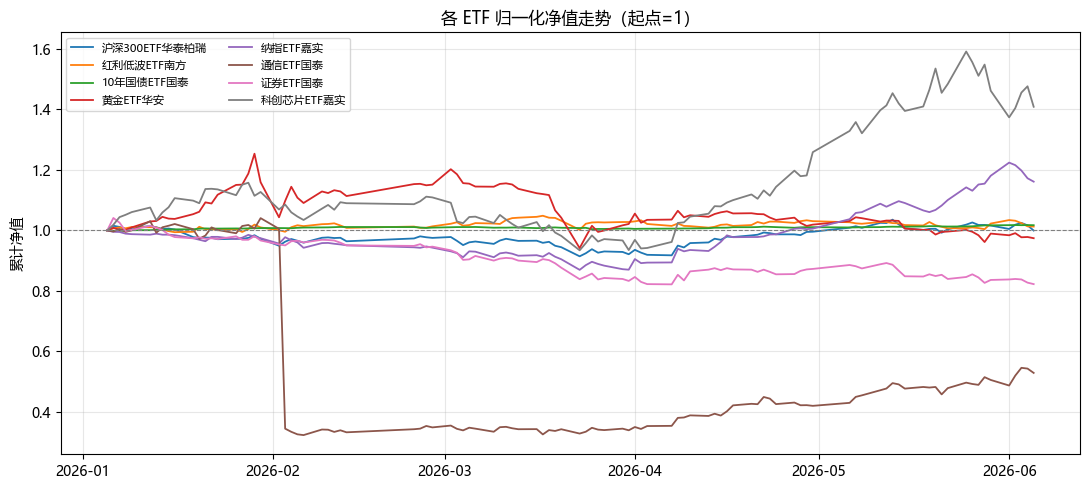

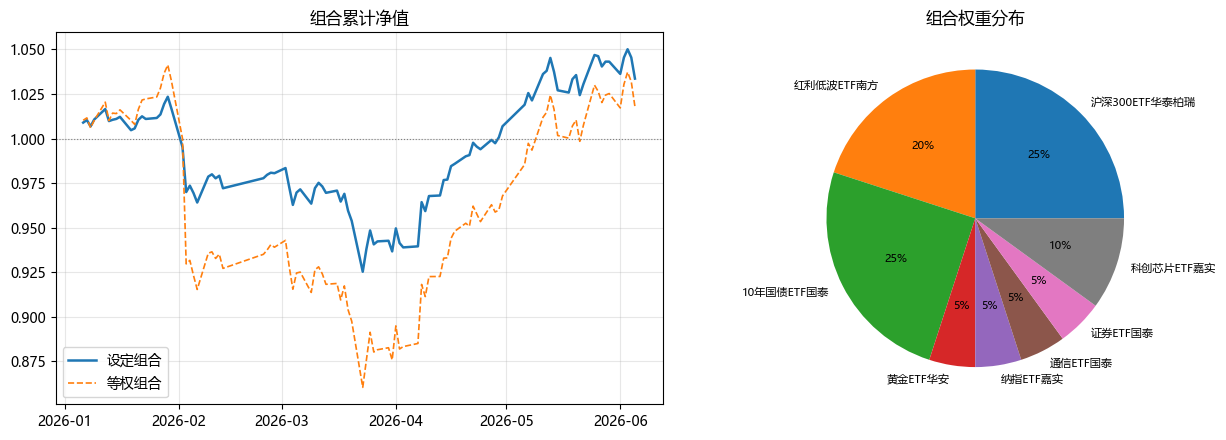

========== 组合 vs 等权 ==========
  组合区间收益率: 设定   3.36%   等权   1.78%
  组合年化波动率: 设定  13.02%   等权  20.86%
  组合最大回撤: 设定  -9.60%   等权 -17.38%
  组合夏普比率: 设定 0.57   等权 0.23


In [8]:
# 归一化价格走势（起点=1）
norm = price_df / price_df.iloc[0]
fig_norm = plt.figure(figsize=(11, 5))
for c in norm.columns:
    plt.plot(norm.index, norm[c], label=c, linewidth=1.3)
plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
plt.title('各 ETF 归一化净值走势（起点=1）'); plt.ylabel('累计净值')
plt.legend(fontsize=8, ncol=2); plt.grid(alpha=0.3); plt.tight_layout()
CHARTS['norm'] = _b64(fig_norm)
plt.show()

def simulate_portfolio(returns_df, weights):
    w = pd.Series(weights, dtype=float)
    cols = [c for c in w.index if c in returns_df.columns]
    if not cols:
        return None, None, None
    w = w[cols] / w[cols].sum()
    port_ret = (returns_df[cols] * w).sum(axis=1)
    port_nav = (1 + port_ret).cumprod()
    ann_vol = port_ret.std(ddof=1) * np.sqrt(TRADING_DAYS)
    ann_ret = port_ret.mean() * TRADING_DAYS
    stats = {
        '组合区间收益率': port_nav.iloc[-1] - 1,
        '组合年化波动率': ann_vol,
        '组合最大回撤':   max_drawdown(port_nav),
        '组合夏普比率':   (ann_ret - RF_ANNUAL) / ann_vol if ann_vol > 0 else np.nan,
    }
    return stats, port_nav, w

port_stats, port_nav, norm_w = simulate_portfolio(ret_df, PORTFOLIO)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
# 组合净值 vs 等权
eq_stats, eq_nav, _ = simulate_portfolio(ret_df, {c: 1 for c in price_df.columns})
axes[0].plot(port_nav.index, port_nav.values, label='设定组合', linewidth=1.8)
axes[0].plot(eq_nav.index, eq_nav.values, label='等权组合', linewidth=1.2, linestyle='--')
axes[0].axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
axes[0].set_title('组合累计净值'); axes[0].legend(); axes[0].grid(alpha=0.3)
# 权重饼图
axes[1].pie(norm_w.values, labels=norm_w.index, autopct='%1.0f%%', textprops={'fontsize': 8})
axes[1].set_title('组合权重分布')
plt.tight_layout()
CHARTS['port'] = _b64(fig)
plt.show()

print('========== 组合 vs 等权 ==========')
for k in ['组合区间收益率', '组合年化波动率', '组合最大回撤']:
    print(f'  {k}: 设定 {pct(port_stats[k])}   等权 {pct(eq_stats[k])}')
print(f"  组合夏普比率: 设定 {port_stats['组合夏普比率']:.2f}   等权 {eq_stats['组合夏普比率']:.2f}")

## 7. 单只 ETF 的定位与修改建议

In [9]:
def single_etf_report(name):
    if name not in score_df.index:
        return f'【{name}】不在结果中（可能取数失败或不在 ETF_LIST）。'
    m = metric_df.loc[name]
    role = score_df.loc[name, '建议分类']
    note = score_df.loc[name, '判定说明']
    scale = liquidity_df.loc[name, '规模(亿)']
    turn  = liquidity_df.loc[name, '日均成交额(万)']
    prem  = liquidity_df.loc[name, '折溢价率(%)']
    w_in  = PORTFOLIO.get(name, None)

    L = []
    L.append('=' * 56)
    L.append(f'【{name}】 定位：{role}    （{note}）')
    L.append('-' * 56)
    L.append(f'  区间收益率 {pct(m["区间收益率"])} | 年化波动率 {pct(m["年化波动率"])} | '
             f'最大回撤 {pct(m["最大回撤"])} | 夏普 {m["夏普比率"]:.2f}')
    L.append(f'  近20日动量 {pct(m["近20日动量"])} | 均线多头排列 {m["多头排列"]} | '
             f'规模 {scale:.1f}亿 | 日均成交 {turn:.0f}万 | 折溢价 {prem:.2f}%（{premium_grade(name, prem)[0]}）')
    if w_in is not None:
        L.append(f'  当前组合权重：{w_in*100:.0f}%')
    L.append('-' * 56)
    L.append('  修改建议：')

    sug = []
    # 流动性
    if role == '淘汰':
        rs = liquidity_reasons(name, scale, turn, prem)
        sug.append('流动性不达标（' + '；'.join(rs) + '）：建议剔除，或换成同类中规模更大、成交更活跃、折溢价更小的替代品。')
    else:
        if pd.notna(scale) and scale < 30:
            sug.append(f'规模仅 {scale:.0f}亿（达标但不算大），大额进出注意冲击成本，优先选≥30-50亿的同类。')
        pg = premium_grade(name, prem)[0]
        if is_qdii(name) and pg == '略有风险':
            sug.append(f'折溢价 {prem:.2f}%（QDII/跨境，处5%~8%「略有风险」档）：可持有但留意溢价收敛，尽量贴近净值买入。')
        elif is_qdii(name) and pg == '很棒':
            sug.append(f'折溢价 {prem:.2f}%（QDII/跨境，≤5%「很棒」档）：折溢价健康。')
        elif pd.notna(prem) and abs(prem) > 0.3:
            sug.append(f'折溢价 {prem:.2f}% 偏离0较多，留意溢价收敛风险，尽量在贴近净值时买入。')

    # 角色适配
    if m['年化波动率'] >= CORE_VOL_CAP or m['最大回撤'] <= CORE_MDD_CAP:
        sug.append(f'波动/回撤偏大（年化波动 {pct(m["年化波动率"])}、回撤 {pct(m["最大回撤"])}），'
                   f'不适合做核心打底，只宜小仓位做进攻型卫星，并设好止损。')
    else:
        sug.append('波动与回撤均较温和，适合作为核心仓打底，可给较高权重求稳。')

    # 动量
    if role == '卫星':
        sug.append('动量在线（多头排列/近20日为正），可作为进攻卫星持有，但需跟踪均线是否走坏、份额是否净流入。')
    elif role == '观察' and m['年化波动率'] >= CORE_VOL_CAP:
        sug.append('当前动量不足或处于回调：进攻仓暂不宜放它，等均线重新多头排列、放量突破再考虑。')

    # 相关性
    if name in corr.columns:
        others = corr[name].drop(name).sort_values(ascending=False)
        if len(others):
            hi, hv = others.index[0], others.iloc[0]
            lo, lv = others.index[-1], others.iloc[-1]
            if hv > CORR_HIGH:
                sug.append(f'与「{hi}」相关性高达 {hv:.2f}（高度重叠），二者保留其一即可，避免伪分散。')
            sug.append(f'与「{lo}」相关性最低（{lv:.2f}），二者搭配能有效分散、压低组合回撤。')

    # 夏普性价比
    med_sharpe = metric_df['夏普比率'].median()
    if pd.notna(m['夏普比率']) and m['夏普比率'] < med_sharpe:
        sug.append(f'夏普 {m["夏普比率"]:.2f} 低于候选池中位数 {med_sharpe:.2f}，单位风险回报一般，权重不宜过高。')

    for i, s in enumerate(sug, 1):
        L.append(f'    {i}. {s}')
    return '\n'.join(L)

targets = [FOCUS_ETF] if FOCUS_ETF else list(score_df.index)
for t in targets:
    print(single_etf_report(t))
    print()

【科创芯片ETF嘉实】 定位：卫星    （有正动量/多头排列，可做进攻）
--------------------------------------------------------
  区间收益率  40.89% | 年化波动率  44.94% | 最大回撤 -19.30% | 夏普 2.13
  近20日动量   6.63% | 均线多头排列 False | 规模 424.2亿 | 日均成交 369354万 | 折溢价 0.20%（正常）
  当前组合权重：10%
--------------------------------------------------------
  修改建议：
    1. 波动/回撤偏大（年化波动  44.94%、回撤 -19.30%），不适合做核心打底，只宜小仓位做进攻型卫星，并设好止损。
    2. 动量在线（多头排列/近20日为正），可作为进攻卫星持有，但需跟踪均线是否走坏、份额是否净流入。
    3. 与「红利低波ETF南方」相关性最低（-0.13），二者搭配能有效分散、压低组合回撤。



## 8. 投资组合综合评估报告

In [10]:
def portfolio_report():
    L = []
    cols = [c for c in PORTFOLIO if c in price_df.columns]
    w = pd.Series({c: PORTFOLIO[c] for c in cols}, dtype=float); w = w / w.sum()

    L.append('╔' + '═' * 54 + '╗')
    L.append('║' + '  投资组合综合评估报告'.ljust(50) + '║')
    L.append('╚' + '═' * 54 + '╝')
    L.append(f'数据区间：{str(price_df.index.min())[:10]} ~ {str(price_df.index.max())[:10]}'
             f'（{len(price_df)} 个交易日，{len(cols)} 只成分）')
    L.append('')

    # 1) 组合指标
    L.append('一、组合绩效')
    L.append(f'   区间收益率 {pct(port_stats["组合区间收益率"])} ｜ 年化波动率 {pct(port_stats["组合年化波动率"])} '
             f'｜ 最大回撤 {pct(port_stats["组合最大回撤"])} ｜ 夏普比率 {port_stats["组合夏普比率"]:.2f}')
    better = '优于' if port_stats['组合夏普比率'] >= eq_stats['组合夏普比率'] else '低于'
    L.append(f'   对比等权组合（夏普 {eq_stats["组合夏普比率"]:.2f}）：当前权重配置夏普{better}等权，'
             f'回撤 {pct(port_stats["组合最大回撤"])} vs 等权 {pct(eq_stats["组合最大回撤"])}。')
    L.append('')

    # 2) 仓位结构（核心/卫星/观察/淘汰）
    L.append('二、仓位结构（核心打底 vs 卫星进攻）')
    role_w = {}
    for c in cols:
        role_w[score_df.loc[c, '建议分类']] = role_w.get(score_df.loc[c, '建议分类'], 0) + w[c]
    for r in ['核心', '卫星', '观察', '淘汰']:
        if r in role_w:
            L.append(f'   {r}：{role_w[r]*100:4.0f}%   ' +
                     '，'.join(f'{c}({w[c]*100:.0f}%)' for c in cols if score_df.loc[c,'建议分类']==r))
    core_w = role_w.get('核心', 0); sat_w = role_w.get('卫星', 0)
    if core_w >= 0.7:
        L.append(f'   ✔ 核心仓位 {core_w*100:.0f}%（≥70%），结构偏稳健，符合「低风险打底」原则。')
    elif core_w >= 0.5:
        L.append(f'   ○ 核心仓位 {core_w*100:.0f}%，攻守较均衡；若想更稳可再提高核心比重。')
    else:
        L.append(f'   ⚠ 核心仓位仅 {core_w*100:.0f}%，组合偏进攻，回撤风险较高，建议增配宽基/红利/债券类核心。')
    if sat_w > 0.3:
        L.append(f'   ⚠ 卫星(进攻)仓位 {sat_w*100:.0f}% 偏高（建议≤30%），波动会被放大，注意控制。')
    if role_w.get('淘汰', 0) > 0:
        bad = [c for c in cols if score_df.loc[c,'建议分类']=='淘汰']
        L.append(f'   ⚠ 组合中含流动性不达标成分：{("、".join(bad))}（合计 {role_w["淘汰"]*100:.0f}%），建议剔除或替换。')
    L.append('')

    # 3) 分散度（相关性）
    L.append('三、分散度与相关性')
    sub = corr.loc[cols, cols]
    iu = np.triu_indices(len(cols), k=1)
    avg_corr = None
    if len(iu[0]):
        pair_vals = sub.values[iu]
        avg_corr = float(np.mean(pair_vals))
        L.append(f'   成分两两平均相关性 {avg_corr:.2f}（越低越分散）。')
        # 最高相关对
        amax = int(np.argmax(pair_vals)); amin = int(np.argmin(pair_vals))
        hi_pair = (cols[iu[0][amax]], cols[iu[1][amax]]); hv = pair_vals[amax]
        lo_pair = (cols[iu[0][amin]], cols[iu[1][amin]]); lv = pair_vals[amin]
        if hv > CORR_HIGH:
            L.append(f'   ⚠ 最高相关：「{hi_pair[0]}」×「{hi_pair[1]}」= {hv:.2f}（重叠，建议二选一或降权）。')
        else:
            L.append(f'   最高相关：「{hi_pair[0]}」×「{hi_pair[1]}」= {hv:.2f}（尚可）。')
        L.append(f'   ✔ 最佳对冲：「{lo_pair[0]}」×「{lo_pair[1]}」= {lv:.2f}（低相关，分散效果好）。')
    L.append('')

    # 4) 集中度
    L.append('四、集中度')
    top = w.sort_values(ascending=False)
    L.append(f'   最大单一权重：{top.index[0]} {top.iloc[0]*100:.0f}%；前三大合计 {top.head(3).sum()*100:.0f}%。')
    if top.iloc[0] > 0.4:
        L.append('   ⚠ 单一成分权重>40%，集中度偏高，组合表现高度依赖它，建议适度分散。')
    L.append('')

    # 5) 结论与建议
    L.append('五、结论与建议')
    v = port_stats['组合年化波动率']
    if v < 0.10:
        style = '稳健保守型'
    elif v < 0.18:
        style = '稳健均衡型'
    else:
        style = '积极进攻型'
    L.append(f'   ● 组合风格：{style}（年化波动 {pct(v)}、最大回撤 {pct(port_stats["组合最大回撤"])}）。')
    advice = []
    if port_stats['组合夏普比率'] < eq_stats['组合夏普比率']:
        advice.append('当前权重夏普低于等权，说明高权重押在了性价比偏低的品种上，建议向高夏普成分倾斜。')
    if sat_w > 0.3:
        advice.append('适当下调高波动卫星权重至总仓位30%以内，可明显降低组合回撤。')
    if avg_corr is not None and avg_corr > 0.6:
        advice.append('成分相关性整体偏高，建议引入低相关资产（如债券、黄金、跨境）以增强分散。')
    if role_w.get('淘汰', 0) > 0:
        advice.append('剔除流动性不达标成分，避免进出困难与折溢价回归损耗。')
    if not advice:
        advice.append('结构合理：核心打底、卫星进攻、相关性可控，维持当前配置并定期（如月度）再平衡即可。')
    for i, a in enumerate(advice, 1):
        L.append(f'   {i}. {a}')
    L.append('')
    L.append('   ※ 以上均为基于历史数据的客观测算，不构成投资建议；实盘需结合趋势、估值、事件风险与个人风险偏好。')
    return '\n'.join(L)

print(portfolio_report())

╔══════════════════════════════════════════════════════╗
║  投资组合综合评估报告                                      ║
╚══════════════════════════════════════════════════════╝
数据区间：2026-01-05 ~ 2026-06-05（100 个交易日，8 只成分）

一、组合绩效
   区间收益率   3.36% ｜ 年化波动率  13.02% ｜ 最大回撤  -9.60% ｜ 夏普比率 0.57
   对比等权组合（夏普 0.23）：当前权重配置夏普优于等权，回撤  -9.60% vs 等权 -17.38%。

二、仓位结构（核心打底 vs 卫星进攻）
   核心：  70%   沪深300ETF华泰柏瑞(25%)，红利低波ETF南方(20%)，10年国债ETF国泰(25%)
   卫星：  10%   科创芯片ETF嘉实(10%)
   观察：  15%   黄金ETF华安(5%)，通信ETF国泰(5%)，证券ETF国泰(5%)
   淘汰：   5%   纳指ETF嘉实(5%)
   ✔ 核心仓位 70%（≥70%），结构偏稳健，符合「低风险打底」原则。
   ⚠ 组合中含流动性不达标成分：纳指ETF嘉实（合计 5%），建议剔除或替换。

三、分散度与相关性
   成分两两平均相关性 0.23（越低越分散）。
   最高相关：「沪深300ETF华泰柏瑞」×「证券ETF国泰」= 0.71（尚可）。
   ✔ 最佳对冲：「红利低波ETF南方」×「科创芯片ETF嘉实」= -0.13（低相关，分散效果好）。

四、集中度
   最大单一权重：沪深300ETF华泰柏瑞 25%；前三大合计 70%。

五、结论与建议
   ● 组合风格：稳健均衡型（年化波动  13.02%、最大回撤  -9.60%）。
   1. 剔除流动性不达标成分，避免进出困难与折溢价回归损耗。

   ※ 以上均为基于历史数据的客观测算，不构成投资建议；实盘需结合趋势、估值、事件风险与个人风险偏好。


## 9. 导出结果到 Excel

In [11]:
with pd.ExcelWriter(OUTPUT_XLSX) as xw:
    score_df.to_excel(xw, sheet_name='汇总评分')
    metric_df.to_excel(xw, sheet_name='指标明细')
    liquidity_df.to_excel(xw, sheet_name='流动性')
    corr.round(4).to_excel(xw, sheet_name='相关性矩阵')
    price_df.to_excel(xw, sheet_name='收盘价')
    if port_stats:
        pd.DataFrame([port_stats]).to_excel(xw, sheet_name='组合指标', index=False)
print(f'已导出：{OUTPUT_XLSX}')

已导出：ETF分析结果.xlsx


## 10. 一键生成可视化 HTML 报告（汇总全部结果）

已生成可视化报告：ETF分析报告.html（465,204 字符）



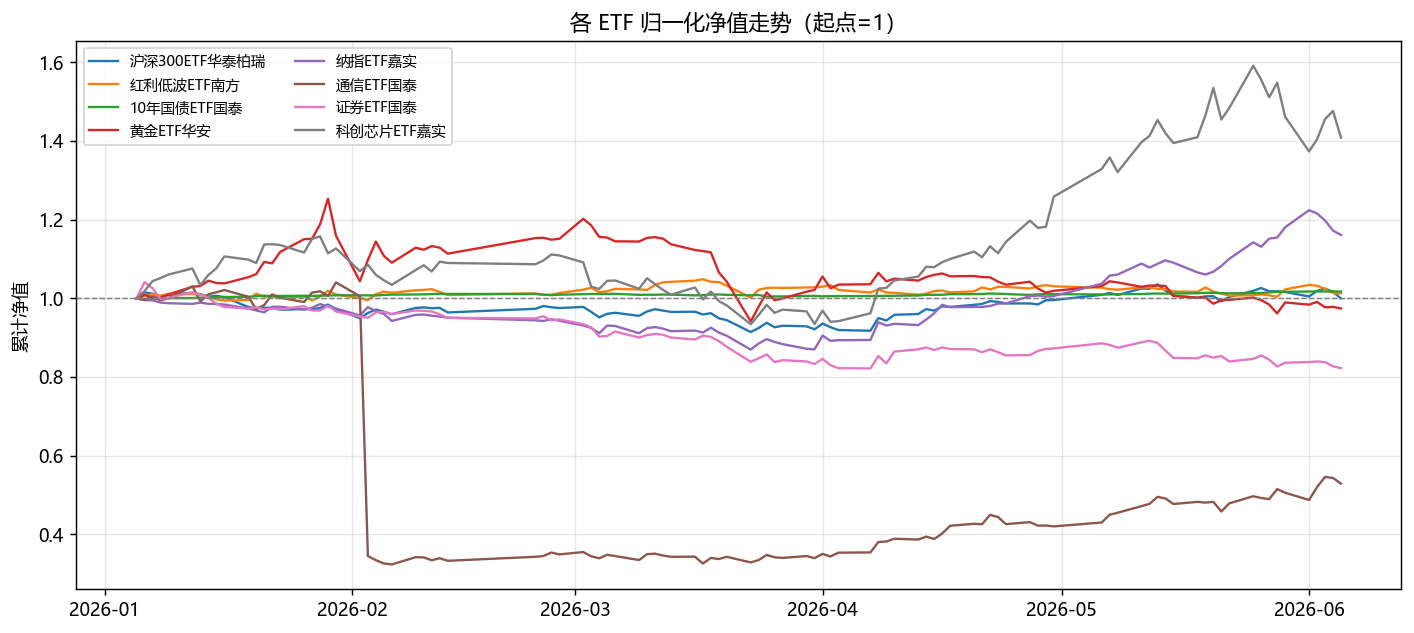
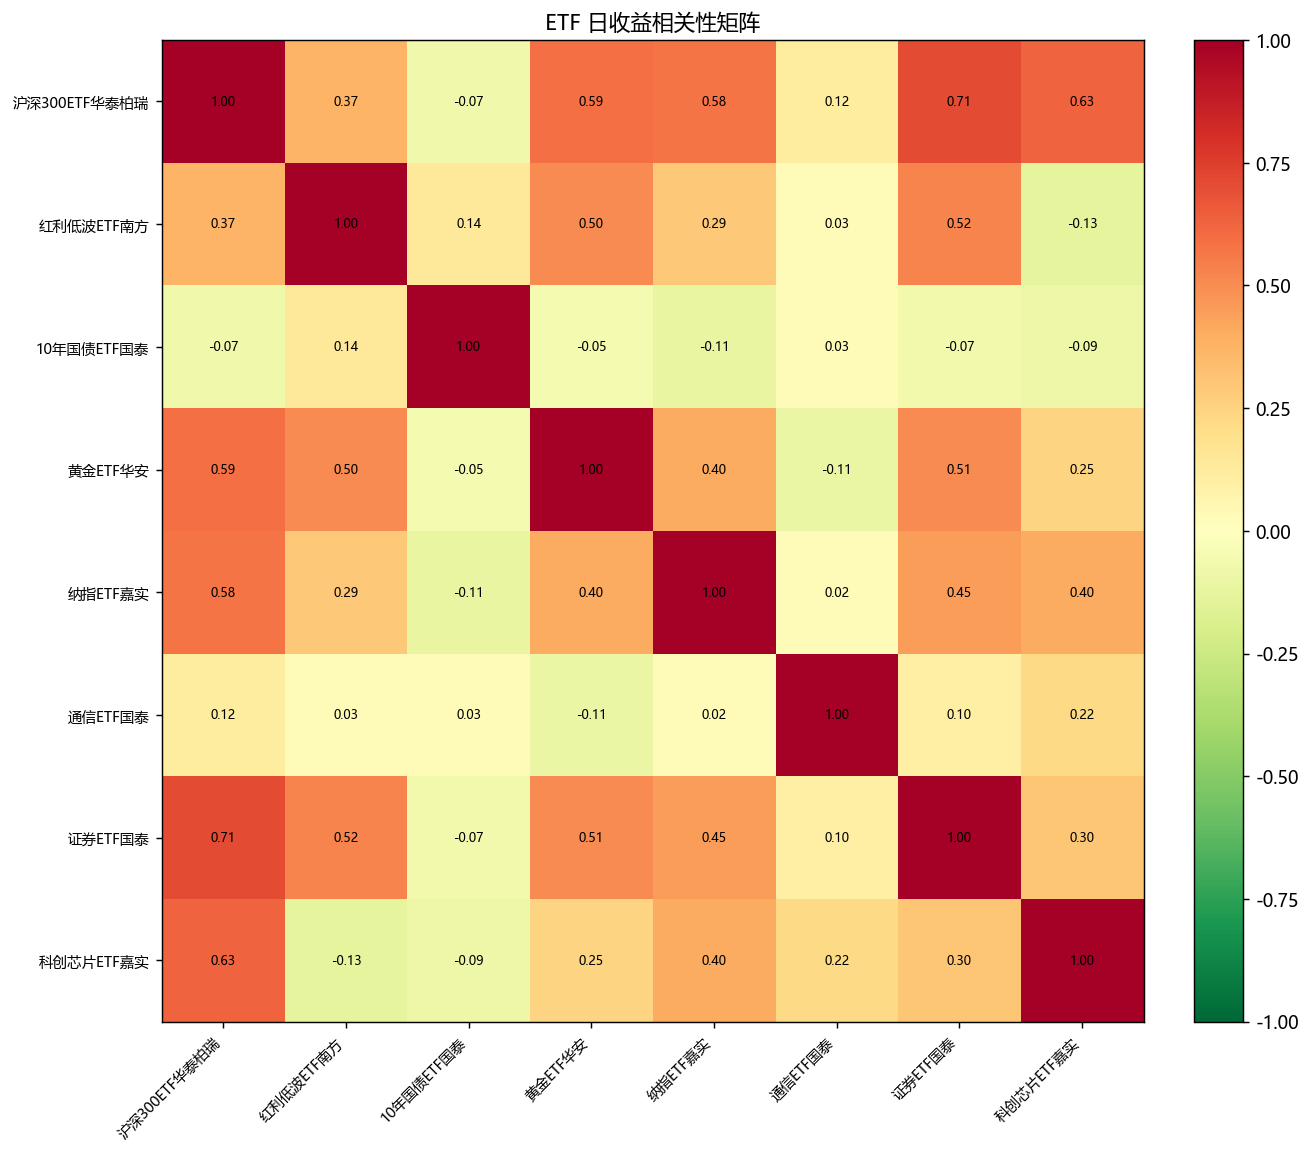
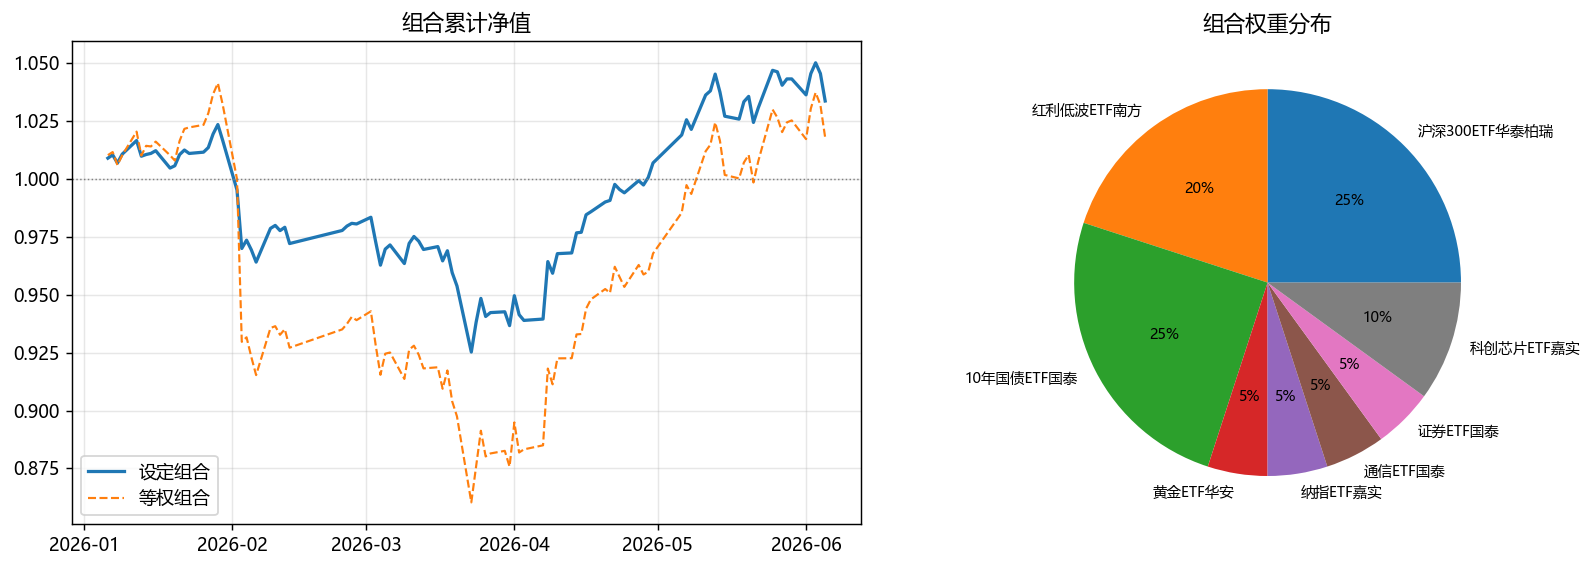

In [12]:
# ============================================================
# 10. 汇总所有结果 → 单页可视化 HTML 报告（样式美观、清晰）
# ============================================================
import html as _html
from datetime import datetime
import matplotlib.pyplot as _plt
import matplotlib.colors as _mc

OUTPUT_HTML = globals().get('OUTPUT_HTML', 'ETF分析报告.html')

def _pc(x):
    return f'{x*100:.2f}%' if pd.notna(x) else 'n/a'

def _colnum(x):
    if pd.isna(x):
        return '<span class="muted">n/a</span>'
    cls = 'pos' if x > 0 else ('neg' if x < 0 else '')
    return f'<span class="{cls}">{x*100:.2f}%</span>'

def _colsharpe(x):
    if pd.isna(x):
        return '<span class="muted">n/a</span>'
    cls = 'pos' if x > 0 else 'neg'
    return f'<span class="{cls}">{x:.2f}</span>'

ROLE_BADGE = {'核心': 'b-core', '卫星': 'b-sat', '观察': 'b-watch', '淘汰': 'b-elim'}
GRADE_BADGE = {'很棒': 'g-good', '正常': 'g-good', '略有风险': 'g-warn', '风险大': 'g-bad', '未知': 'g-mut'}

def _badge(text, mapping):
    cls = mapping.get(str(text), 'g-mut')
    return f'<span class="badge {cls}">{_html.escape(str(text))}</span>'

def _bull(v):
    if v == True:
        return '<span class="pos">✔ 多头</span>'
    if pd.isna(v):
        return '<span class="muted">—</span>'
    return '<span class="neg">✘</span>'

_cmap = _plt.get_cmap('RdYlGn_r')
def _heat_bg(v):
    return _mc.to_hex(_cmap((float(v) + 1) / 2))

CSS = """
* { box-sizing: border-box; }
body { margin:0; font-family:'Microsoft YaHei','Segoe UI',Arial,sans-serif; background:#f4f6fb; color:#1f2937; line-height:1.5; }
.wrap { max-width:1180px; margin:0 auto; padding:28px 22px 60px; }
.hero { background:linear-gradient(135deg,#4f46e5,#7c3aed); color:#fff; border-radius:18px; padding:30px 34px; box-shadow:0 12px 32px rgba(79,70,229,.28); }
.hero h1 { margin:0 0 6px; font-size:26px; font-weight:700; }
.hero .sub { opacity:.92; font-size:13.5px; }
.hero .meta { margin-top:18px; display:flex; gap:30px; flex-wrap:wrap; }
.hero .meta span { display:block; opacity:.8; font-size:12px; margin-bottom:2px; }
.hero .meta b { font-size:15px; font-weight:600; }
section { margin-top:30px; }
h2 { font-size:18px; border-left:4px solid #4f46e5; padding-left:11px; margin:0 0 16px; color:#312e81; }
h3 { font-size:14px; margin:0 0 12px; color:#475569; }
.cards { display:grid; grid-template-columns:repeat(4,1fr); gap:16px; }
.kpi { background:#fff; border-radius:14px; padding:18px 20px; box-shadow:0 2px 12px rgba(15,23,42,.06); }
.kpi .label { font-size:13px; color:#6b7280; }
.kpi .value { font-size:25px; font-weight:700; margin-top:6px; }
.kpi .cmp { font-size:12px; color:#9ca3af; margin-top:5px; }
.card { background:#fff; border-radius:14px; padding:20px; box-shadow:0 2px 12px rgba(15,23,42,.06); overflow-x:auto; }
table.tbl { width:100%; border-collapse:collapse; font-size:13px; }
table.tbl th { background:#eef2ff; color:#3730a3; text-align:right; padding:10px 12px; font-weight:600; white-space:nowrap; }
table.tbl th:first-child, table.tbl td:first-child { text-align:left; }
table.tbl td { padding:9px 12px; border-bottom:1px solid #f1f1f6; text-align:right; white-space:nowrap; }
table.tbl tbody tr:hover td { background:#fafaff; }
td.wrap-td { white-space:normal; min-width:220px; color:#4b5563; text-align:left; }
.badge { display:inline-block; padding:2px 10px; border-radius:999px; font-size:12px; font-weight:600; }
.b-core{background:#dcfce7;color:#166534;} .b-sat{background:#dbeafe;color:#1e40af;}
.b-watch{background:#fef3c7;color:#92400e;} .b-elim{background:#fee2e2;color:#991b1b;}
.g-good{background:#dcfce7;color:#166534;} .g-warn{background:#fef3c7;color:#92400e;}
.g-bad{background:#fee2e2;color:#991b1b;} .g-mut{background:#f3f4f6;color:#6b7280;}
.pos{color:#dc2626;font-weight:600;} .neg{color:#16a34a;font-weight:600;} .muted{color:#9ca3af;}
.chart-grid { display:grid; grid-template-columns:1fr 1fr; gap:18px; }
.chart img { width:100%; height:auto; border-radius:8px; display:block; }
.chart { margin-bottom:18px; }
pre.report { background:#0f172a; color:#e2e8f0; border-radius:14px; padding:22px 24px; font-size:12.5px; line-height:1.65; overflow-x:auto; white-space:pre; font-family:'Cascadia Code','Consolas','Microsoft YaHei',monospace; box-shadow:0 2px 12px rgba(15,23,42,.12); }
.note { color:#94a3b8; font-size:12px; margin-top:30px; text-align:center; line-height:1.8; }
@media(max-width:760px){ .cards{grid-template-columns:repeat(2,1fr);} .chart-grid{grid-template-columns:1fr;} }
"""

# ---- KPI 卡片：组合绩效 ----
kpi_defs = [
    ('组合区间收益率', port_stats['组合区间收益率'], eq_stats['组合区间收益率'], 'pct'),
    ('组合年化波动率', port_stats['组合年化波动率'], eq_stats['组合年化波动率'], 'pct'),
    ('组合最大回撤',   port_stats['组合最大回撤'],   eq_stats['组合最大回撤'],   'pct'),
    ('组合夏普比率',   port_stats['组合夏普比率'],   eq_stats['组合夏普比率'],   'num'),
]
_kpi = []
for label, val, eqv, kind in kpi_defs:
    if kind == 'pct':
        vtxt, cmp = _colnum(val), f'等权 {_pc(eqv)}'
    else:
        vtxt, cmp = _colsharpe(val), f'等权 {eqv:.2f}'
    _kpi.append(f'<div class="kpi"><div class="label">{label}</div><div class="value">{vtxt}</div><div class="cmp">{cmp}</div></div>')
kpi_html = '\n'.join(_kpi)

# ---- 汇总评分表 ----
heads = ['ETF名称','区间收益率','年化波动率','最大回撤','夏普比率','规模(亿)','日均成交额(万)','折溢价率(%)','折溢价评级','多头排列','建议分类','判定说明']
th = ''.join(f'<th>{h}</th>' for h in heads)
trs = []
for name, r in score_df.iterrows():
    scale, turn, prem = r['规模(亿)'], r['日均成交额(万)'], r['折溢价率(%)']
    scale_s = f'{scale:.1f}' if pd.notna(scale) else '—'
    turn_s  = f'{turn:,.0f}' if pd.notna(turn) else '—'
    prem_s  = f'{prem:.2f}' if pd.notna(prem) else '—'
    trs.append(
        '<tr>'
        f'<td>{_html.escape(str(name))}</td>'
        f'<td>{_colnum(r["区间收益率"])}</td>'
        f'<td>{_colnum(r["年化波动率"])}</td>'
        f'<td>{_colnum(r["最大回撤"])}</td>'
        f'<td>{_colsharpe(r["夏普比率"])}</td>'
        f'<td>{scale_s}</td><td>{turn_s}</td><td>{prem_s}</td>'
        f'<td>{_badge(r["折溢价评级"], GRADE_BADGE)}</td>'
        f'<td>{_bull(r["多头排列"])}</td>'
        f'<td>{_badge(r["建议分类"], ROLE_BADGE)}</td>'
        f'<td class="wrap-td">{_html.escape(str(r["判定说明"]))}</td>'
        '</tr>'
    )
summary_table = f'<table class="tbl"><thead><tr>{th}</tr></thead><tbody>{"".join(trs)}</tbody></table>'

# ---- 流动性表 ----
lq_th = ''.join(f'<th>{h}</th>' for h in ['ETF名称','规模(亿)','日均成交额(万)','折溢价率(%)'])
lq_trs = []
for name, r in liquidity_df.iterrows():
    s, t, p = r['规模(亿)'], r['日均成交额(万)'], r['折溢价率(%)']
    s_s = f'{s:.1f}' if pd.notna(s) else '—'
    t_s = f'{t:,.0f}' if pd.notna(t) else '—'
    p_s = f'{p:.3f}' if pd.notna(p) else '—'
    lq_trs.append(f'<tr><td>{_html.escape(str(name))}</td><td>{s_s}</td><td>{t_s}</td><td>{p_s}</td></tr>')
liquidity_table = f'<table class="tbl"><thead><tr>{lq_th}</tr></thead><tbody>{"".join(lq_trs)}</tbody></table>'

# ---- 相关性矩阵（热力着色）----
_cc = list(corr.columns)
ch = '<th></th>' + ''.join(f'<th>{_html.escape(str(c))}</th>' for c in _cc)
crs = []
for ri in _cc:
    cells = [f'<td>{_html.escape(str(ri))}</td>']
    for ci in _cc:
        v = corr.loc[ri, ci]
        cells.append(f'<td style="background:{_heat_bg(v)};color:#1f2937;font-weight:600">{v:.2f}</td>')
    crs.append('<tr>' + ''.join(cells) + '</tr>')
corr_table = f'<table class="tbl"><thead><tr>{ch}</tr></thead><tbody>{"".join(crs)}</tbody></table>'

# ---- 图表 ----
def _img(key, title):
    if key not in CHARTS:
        return ''
    return f'<div class="card chart"><h3>{title}</h3><img src="data:image/png;base64,{CHARTS[key]}"/></div>'

# ---- 文字报告 ----
_targets = [FOCUS_ETF] if FOCUS_ETF else list(score_df.index)
single_html = _html.escape('\n\n'.join(single_etf_report(t) for t in _targets))
port_html = _html.escape(portfolio_report())

# ---- 组装 ----
gen_time = datetime.now().strftime('%Y-%m-%d %H:%M')
src_name = '东方财富（前复权 qfq）' if DATA_SOURCE == 'eastmoney' else '新浪财经（不复权）'
d0, d1 = str(price_df.index.min())[:10], str(price_df.index.max())[:10]
roles_txt = '  '.join(f'{k} {v}' for k, v in dict(score_df['建议分类'].value_counts()).items())

html_doc = f"""<!DOCTYPE html>
<html lang="zh-CN"><head><meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>ETF 组合分析报告</title>
<style>{CSS}</style></head>
<body><div class="wrap">
<header class="hero">
  <h1>ETF 组合分析与评估报告</h1>
  <div class="sub">基于 AkShare 历史行情的客观量价测算 · 仅供研究参考，不构成投资建议</div>
  <div class="meta">
    <div><span>数据区间</span><b>{d0} ~ {d1}</b></div>
    <div><span>交易日数</span><b>{len(price_df)} 天</b></div>
    <div><span>成分数量</span><b>{price_df.shape[1]} 只</b></div>
    <div><span>数据源</span><b>{src_name}</b></div>
    <div><span>分类分布</span><b>{roles_txt}</b></div>
    <div><span>生成时间</span><b>{gen_time}</b></div>
  </div>
</header>

<section><h2>组合绩效概览</h2><div class="cards">{kpi_html}</div></section>

<section><h2>候选池评分与四道关分类</h2><div class="card">{summary_table}</div></section>

<section><h2>可视化图表</h2>
  <div class="chart-grid">
    {_img('norm','各 ETF 归一化净值走势（起点 = 1）')}
    {_img('corr','日收益相关性矩阵')}
  </div>
  {_img('port','组合累计净值 vs 等权 · 权重分布')}
</section>

<section><h2>相关性矩阵</h2><div class="card">{corr_table}</div></section>

<section><h2>流动性数据</h2><div class="card">{liquidity_table}</div></section>

<section><h2>单只 ETF 定位与修改建议</h2><pre class="report">{single_html}</pre></section>

<section><h2>投资组合综合评估报告</h2><pre class="report">{port_html}</pre></section>

<div class="note">本报告由 ETF 组合分析工具自动生成 · 指标均为历史回看测算，不预测未来<br>投资有风险，入市需谨慎</div>
</div></body></html>"""

with open(OUTPUT_HTML, 'w', encoding='utf-8') as f:
    f.write(html_doc)
print(f'已生成可视化报告：{OUTPUT_HTML}（{len(html_doc):,} 字符）')

from IPython.display import HTML, display
display(HTML(html_doc))
